# 프로젝트1 : 손수 설계하는 선형회귀, 당뇨병 수치를 맞춰보자!

In [19]:
#당뇨병 데이터셋 불러오기
from sklearn.datasets import load_diabetes 
#테이터셋 로드
diabetes = load_diabetes()
#입력 데이터(x)
df_X = diabetes.data
#정답 데이터(y)
df_y = diabetes.target

#데이터 크기확인
print(df_X.shape)
print(df_y.shape)

(442, 10)
(442,)


In [20]:
import numpy as np
#입력 데이터를 numpy배열로 변환
X = np.array(df_X)

#데이터 확인
print(X.shape)

(442, 10)


In [21]:
#정답 데이터를 numpy배열로 변환
#실제 당뇨병 진행 정도(목표값)
#모델이 예측해야 하는 값
y = np.array(df_y)

#데이터 확인
print(y.shape)

(442,)


In [22]:
from sklearn.model_selection import train_test_split

#데이터를 확습용과 테스트용으로 분리
X_train, X_test, y_train, y_test = train_test_split(X, #입력 데이터
                                                    y, #정답 데이터
                                                    test_size=0.2, #20%를 테스트용으로 사용
                                                    random_state=42 #랜덤 고정
                                                   ) 

#분리결과 확인
print(X_train.shape)
print(X_test.shape)

(353, 10)
(89, 10)


In [23]:
#feature가 10개이므로 가중치도 10개 생성
W = np.random.rand(10)
b = np.random.rand()

print(W)
print(b)

[0.96685342 0.80122715 0.08823585 0.53542842 0.93816153 0.18046698
 0.43416095 0.25384179 0.0865214  0.08070843]
0.754531529814114


In [24]:
def model(X, W, b):
    #예측값 저장 변수
    predictions = 0
    #각 feature와 가중치를 곱함
    for i in range(10):
        predictions += X[:, i] * W[i]
    predictions += b
    
    return predictions

In [25]:
def mse(a, b):
    #오차 제곱 평균 계산
    mse = ((a - b) ** 2).mean()
    
    return mse

In [26]:
def loss(X, W, b, y):

    # 예측값 계산
    predictions = model(X, W, b)

    # MSE 계산. loss 작을수록 좋음
    L = mse(predictions, y)

    return L

In [27]:
def gradient(X, W, b, y):

    # 데이터 개수
    N = len(y)

    # 현재 예측값
    y_pred = model(X, W, b)

    # W에 대한 기울기 계산
    dW = (1 / N) * 2 * X.T.dot(y_pred - y)

    # b에 대한 기울기 계산
    db = 2 * (y_pred - y).mean()

    return dW, db

In [28]:
# 학습 속도 설정
LEARNING_RATE = 0.01

In [33]:
# 10000번 반복 학습
for i in range(12000):

    # 기울기 계산
    dW, db = gradient(X_train,W,b,y_train)

    # 경사하강법 수행
    #현재 위치에서 loss가 감소하는 방향으로 조금 이동
    W -= LEARNING_RATE * dW
    b -= LEARNING_RATE * db

    # 100번마다 loss 출력
    if i % 100 == 0:

        L = loss(X_train,W,b,y_train)

        print(i, L)

0 2979.1707231256228
100 2978.484733544309
200 2977.805044159892
300 2977.131592630013
400 2976.4643172867018
500 2975.8031571278325
600 2975.1480518087196
700 2974.4989416338517
800 2973.8557675487664
900 2973.218471132055
1000 2972.5869945875006
1100 2971.961280736343
1200 2971.341273009664
1300 2970.726915440901
1400 2970.118152658477
1500 2969.514929878546
1600 2968.91719289785
1700 2968.3248880866954
1800 2967.737962382029
1900 2967.1563632806237
2000 2966.580038832375
2100 2966.008937633688
2200 2965.443008820972
2300 2964.882202064233
2400 2964.326467560754
2500 2963.775756028883
2600 2963.230018701897
2700 2962.6892073219683
2800 2962.1532741342126
2900 2961.622171880823
3000 2961.095853795293
3100 2960.574273596718
3200 2960.057385484182
3300 2959.5451441312184
3400 2959.0375046803547
3500 2958.534422737732
3600 2958.0358543677953
3700 2957.541756088064
3800 2957.0520848639726
3900 2956.5667981037795
4000 2956.0858536535466
4100 2955.6092097921905
4200 2955.136825226597
4300 2

In [34]:
# 테스트 데이터 예측
#학습이 끝난 W와 b로 새로운 데이터를 예측
prediction = model(X_test,W,b)

print(prediction[:5])

[144.21354944 175.54895694 143.3237884  287.48134567 126.97969961]


In [35]:
# MSE 계산
mse_value = mse(prediction,y_test)

print("MSE :", mse_value)  #MSE가 작을수록 실제값과 예측값 차이가 작음

MSE : 2864.8578546791146


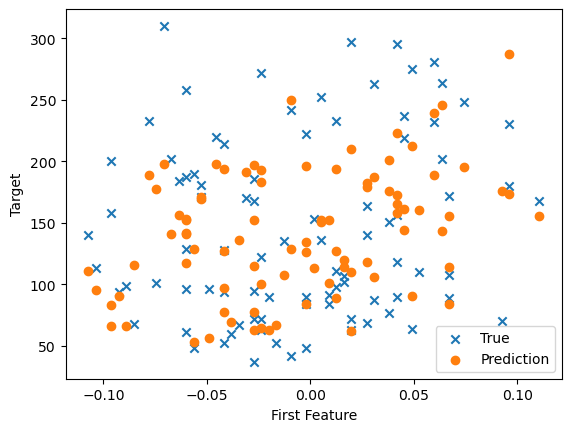

In [36]:
import matplotlib.pyplot as plt

# 실제값
plt.scatter(X_test[:, 0],y_test,label='True', marker='x')

# 예측값
plt.scatter(X_test[:, 0],prediction,label='Prediction')

# x축 이름
plt.xlabel('First Feature')

# y축 이름
plt.ylabel('Target')

# 범례 출력
plt.legend()

# 그래프 출력
plt.show()

# 프로젝트2: 날씨 좋은 월요일 오후 세시, 자전거 타는 사람은 몇 명?

In [37]:
# 데이터 분석용 라이브러리
import pandas as pd

# 자전거 대여 데이터 읽기
train = pd.read_csv('~/data/data/bike-sharing-demand/train.csv')

# 상위 5개 데이터 확인
train.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [38]:
# datetime 컬럼을 날짜 형식(datetime 타입)으로 변환
train['datetime'] = pd.to_datetime(train['datetime'])

# 연도
train['year'] = train['datetime'].dt.year

# 월
train['month'] = train['datetime'].dt.month

# 일
train['day'] = train['datetime'].dt.day

# 시
train['hour'] = train['datetime'].dt.hour

# 분
train['minute'] = train['datetime'].dt.minute

# 초
train['second'] = train['datetime'].dt.second

train.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day,hour,minute,second
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011,1,1,0,0,0
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011,1,1,1,0,0
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011,1,1,2,0,0
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011,1,1,3,0,0
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011,1,1,4,0,0


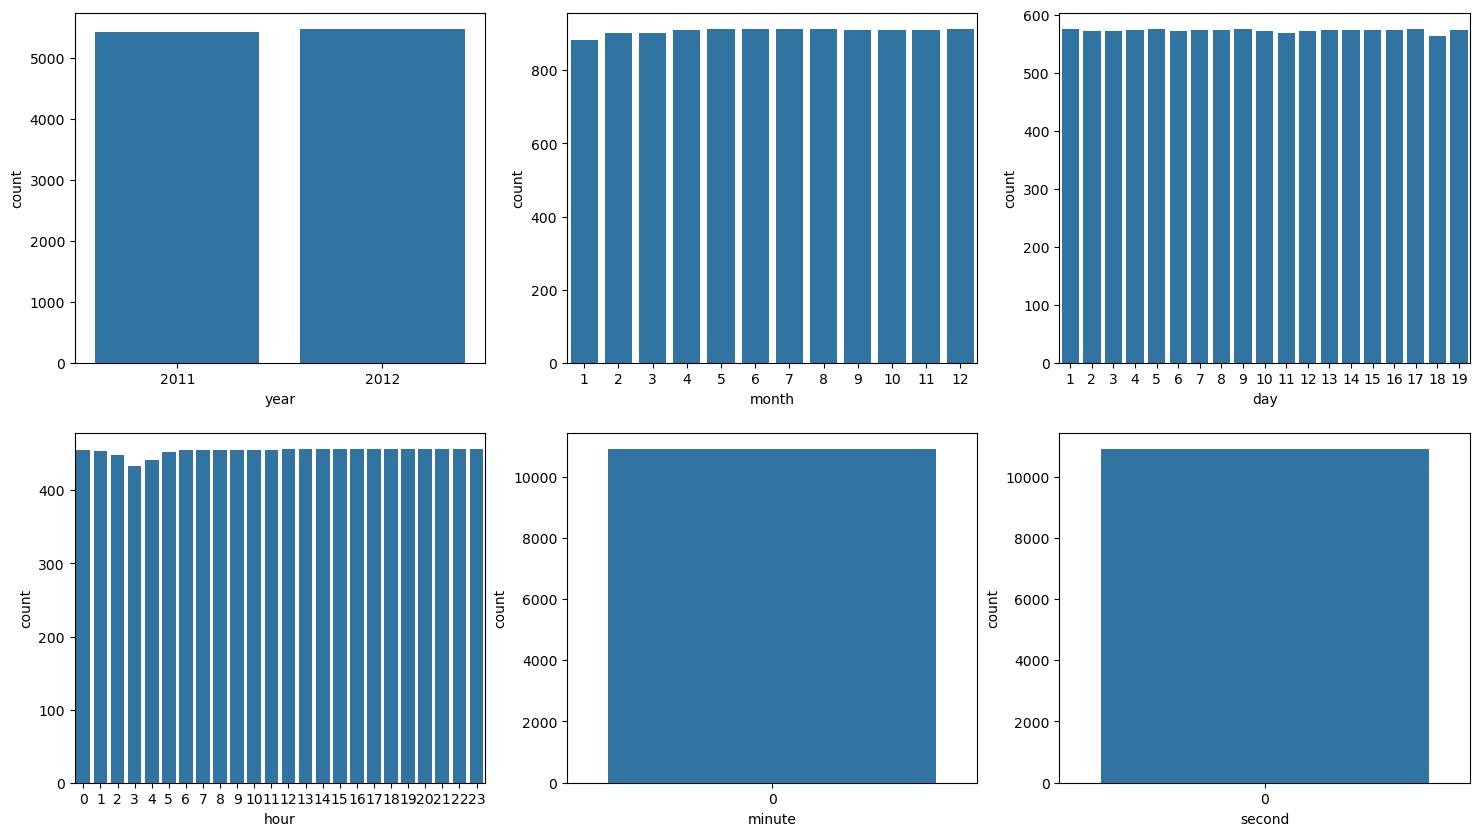

In [39]:
# 그래프 라이브러리
import matplotlib.pyplot as plt
import seaborn as sns

# 2행 3열 그래프 생성
fig, ax = plt.subplots(
    2,          # 행 개수
    3,          # 열 개수
    figsize=(18,10)  # 그래프 크기
)

# 연도별 데이터 개수
sns.countplot(x='year',data=train,ax=ax[0,0])

# 월별 데이터 개수
sns.countplot(x='month',data=train,ax=ax[0,1])

# 일별 데이터 개수
sns.countplot(x='day',data=train,ax=ax[0,2])

# 시간별 데이터 개수
sns.countplot(x='hour',data=train,ax=ax[1,0])

# 분별 데이터 개수
sns.countplot(x='minute',data=train,ax=ax[1,1])

# 초별 데이터 개수
sns.countplot(x='second',data=train,ax=ax[1,2])

# 그래프 출력
plt.show()

In [40]:
# 예측해야 하는 정답 데이터
y = train['count']
# 예측에 사용할 특징(feature) 선택
X = train[['season','holiday','workingday','weather','temp','atemp','humidity','windspeed','year','month','day','hour'
]]

from sklearn.model_selection import train_test_split

# 학습용 80%
# 테스트용 20%
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [41]:
# 선형회귀 모델 불러오기
from sklearn.linear_model import LinearRegression

# 모델 생성
model = LinearRegression()

# 모델 학습
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [42]:
# 테스트 데이터 예측
predictions = model.predict(X_test)

# 앞 10개 출력
print(predictions[:10])

[248.10627003  48.79765547 200.90676727 292.78583227 388.4865481
 316.85337587 182.28731982 299.1421539  172.93889417  13.19173866]


In [43]:
from sklearn.metrics import mean_squared_error

# 평균제곱오차 계산
mse = mean_squared_error(y_test,predictions)

print("MSE :", mse)

MSE : 19945.370053754057


In [44]:
import numpy as np

# 루트를 씌워 실제 오차 크기로 변환
rmse = np.sqrt(mse)

print("RMSE :", rmse)

RMSE : 141.22807813517133


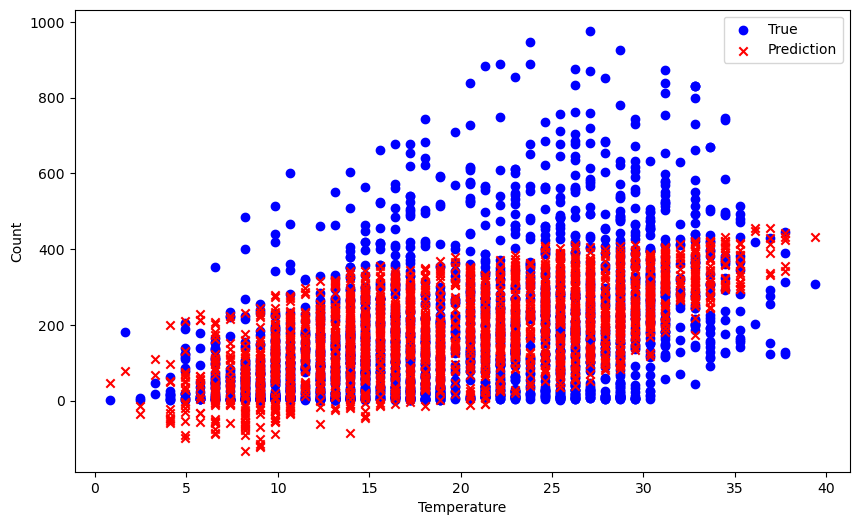

In [45]:
# 그래프 크기 설정
plt.figure(figsize=(10,6))

# 실제값
plt.scatter(X_test['temp'],y_test,color='blue',label='True')

# 예측값
plt.scatter(X_test['temp'],predictions,color='red',marker='x',label='Prediction')

# x축 이름
plt.xlabel('Temperature')

# y축 이름
plt.ylabel('Count')

# 범례 출력
plt.legend()

# 그래프 출력
plt.show()

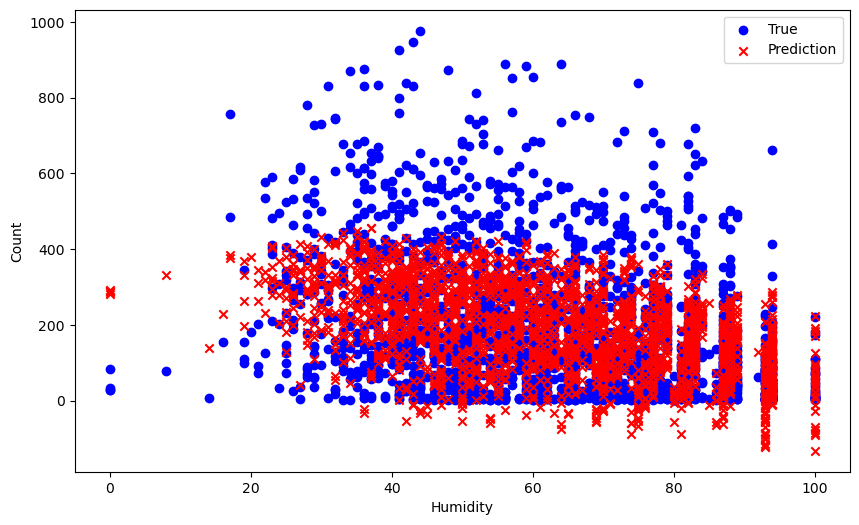

In [46]:
# 그래프 크기 설정
plt.figure(figsize=(10,6))

# 실제값
plt.scatter(X_test['humidity'],y_test,color='blue',label='True')

# 예측값
plt.scatter(X_test['humidity'],predictions,color='red',marker='x',label='Prediction')

# x축 이름
plt.xlabel('Humidity')

# y축 이름
plt.ylabel('Count')

# 범례 출력
plt.legend()

# 그래프 출력
plt.show()